In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
load=pd.read_csv('train.csv')

In [52]:

print(load.shape)
print(load.columns)
print(load.head())
load.info()

(9800, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Day'],
      dtype='object')
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  D

In [56]:

load.columns=load.columns.str.strip().str.lower().str.replace(" ","_")
load.isnull().sum()
load.describe() 

,row_id,order_date,ship_date,sales,year,month,day
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,230.769059,2016.724184,7.818469,15.486837
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,2015.000000,1.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,2016.000000,5.000000,8.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,2017.000000,9.000000,16.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,2018.000000,11.000000,23.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,2018.000000,12.000000,31.000000
std,2829.160653,NaN,NaN,626.651875,1.123984,3.281905,8.753733


In [59]:
load.drop_duplicates(inplace=True)
load['category'].unique()
load['region'].unique()
load['segment'].unique()
load.describe()

,row_id,order_date,ship_date,sales,year,month,day
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,230.769059,2016.724184,7.818469,15.486837
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,2015.000000,1.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,2016.000000,5.000000,8.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,2017.000000,9.000000,16.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,2018.000000,11.000000,23.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,2018.000000,12.000000,31.000000
std,2829.160653,NaN,NaN,626.651875,1.123984,3.281905,8.753733


In [7]:
print(load.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [21]:
load['Order Date'] = pd.to_datetime(load['Order Date'], dayfirst=True)
load['Ship Date'] = pd.to_datetime(load['Ship Date'], dayfirst=True)

In [22]:
load.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [25]:
load['Order Date']=pd.to_datetime(load['Order Date'])
load['Ship Date']=pd.to_datetime(load['Ship Date'])

In [27]:
#creting new columns 
load['Year']=load['Order Date'].dt.year
load['Month']=load['Order Date'].dt.month
load['Day']=load['Order Date'].dt.day

In [28]:
load.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [30]:
load.columns=load.columns.str.strip()

In [31]:
print(load.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Day                       int32
dtype: object


In [32]:
load=load[load['Sales']>0]

In [33]:
# time based analysis
load.groupby('Month')['Sales'].sum()

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

In [34]:
#region analysis
load.groupby('Region')['Sales'].sum()

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

In [35]:
#categorical analysis
load.groupby('Category')['Sales'].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

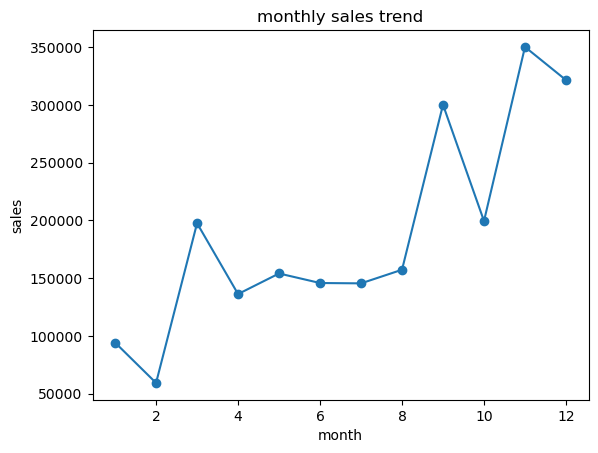

In [38]:
#monthly sales trend
monthly_sales=load.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line',marker='o')
plt.title("monthly sales trend")
plt.xlabel("month")
plt.ylabel("sales")
plt.show()

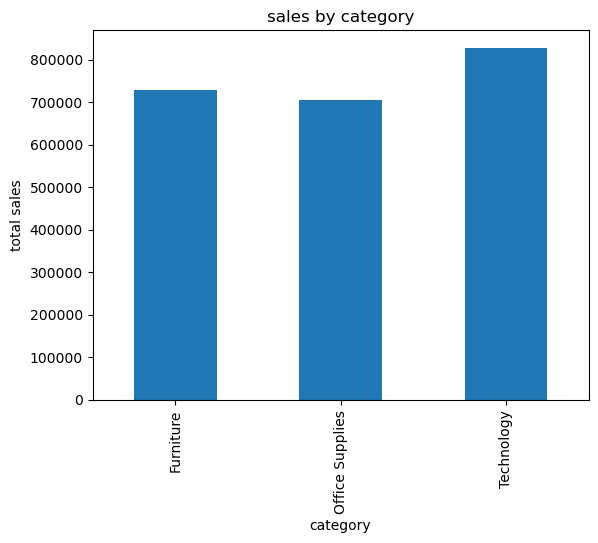

In [36]:
#sales y category
category_sales=load.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("sales by category")
plt.xlabel("category")
plt.ylabel("total sales")
plt.show()

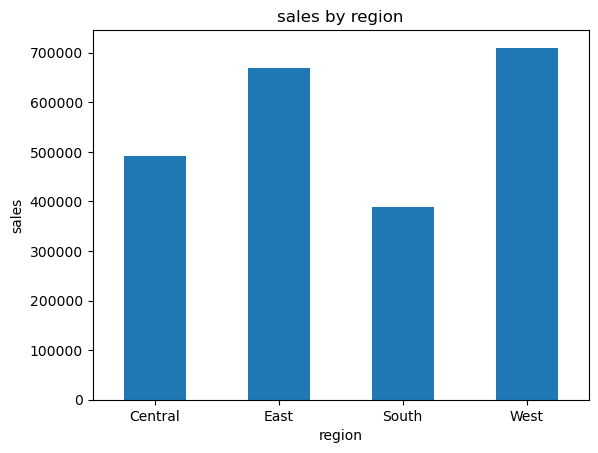

In [65]:
#sales by region
region_sales=load.groupby('region')['sales'].sum()
region_sales.plot(kind='bar')
plt.title("sales by region")
plt.xlabel("region")
plt.ylabel("sales")
plt.xticks(rotation=0)
plt.show()

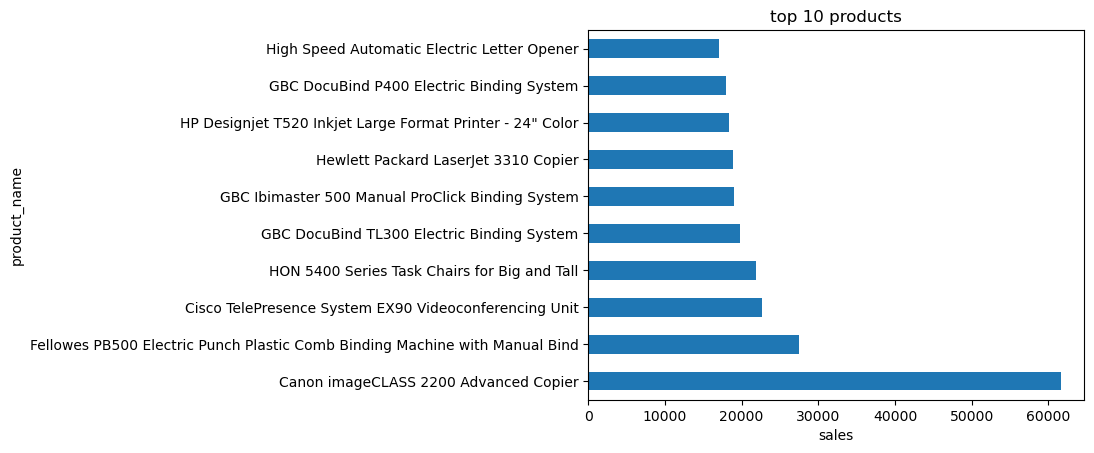

In [69]:
# top 10 products
load.columns = load.columns.str.lower().str.strip()
top_products=load.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')
plt.title("top 10 products")
plt.xlabel("sales")
plt.show()

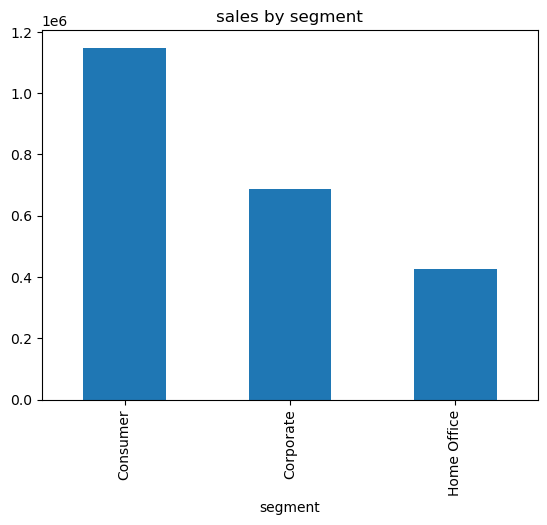

In [70]:
#sales by segment
segment_sales=load.groupby('segment')['sales'].sum()
segment_sales.plot(kind='bar')
plt.title("sales by segment")
plt.show()

In [71]:
load.to_csv("cleaned_superstore.csv",index=False)